# Imports

In [27]:
from tqdm.notebook import tqdm
import numpy as np
import torch
from matplotlib import animation, pyplot as plt

from imagegen.setup import find_root, load_config
import imagegen.unet as unet
import imagegen.train as train
import imagegen.data as data
import imagegen.ddpmeval as ddpmeval
import imagegen.ddpmhuggingface as ddpmhf

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Model & Data
```set epoch, cfg mdl val_dl```

model only has 448k parameters, 1.7mb - small

In [10]:
epoch = 3
saved_model = find_root() / f"saved_models/20250616-1730/model_epoch{epoch:05d}.pt"
cfg = load_config(ddpmeval.CFG_FNAME)
cfg['device'] = 'cpu'

In [11]:
mdl = ddpmeval.load_model(cfg=cfg, saved_model=saved_model)

In [12]:
unet.count_parameters(mdl)

{'total_params': 57646781,
 'trainable_params': 57646781,
 'total_mb': 219.9050178527832}

In [13]:
val_ds = data.get_cached_image_dataset(
    split="val",
    verbose=True,
    root_dir=cfg["data"]["resized_dir"],
)
val_dl = data.get_dataloader(
    split="val",
    verbose=cfg["verbose"],
    batch_size=cfg["data"]["batch_size"],
    ds=val_ds,
)

------ CACHING DATASET val -------


Caching images: 100%|███████████████████████████████████████| 10000/10000 [00:01<00:00, 6981.79it/s]

 -- Creating DataLoader val --


# Sample Image

In [ ]:
def p_sample(model, x, ddpm, t, t_index):
    betas_t = extract(ddpm.betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)
    
    # Equation 11 in the paper
    # Use our model (noise predictor) to predict the mean
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        # Algorithm 2 line 4:
        return model_mean + torch.sqrt(posterior_variance_t) * noise 


In [30]:
xT = torch.randn(1, 3, 64, 64)
epsT = mdl(xT, torch.tensor([200]))


In [32]:
ddpm = train.DDPMTrainer(cfg=cfg)

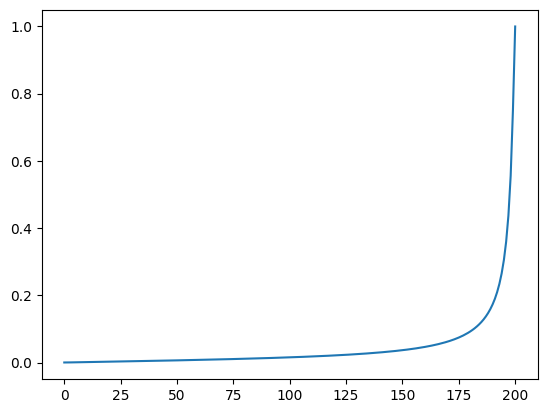

In [34]:
plt.plot(ddpm.betas.detach().numpy())

In [31]:
epsT.size()

torch.Size([1, 3, 64, 64])

In [29]:
ddpmhf.sample(mdl, (64, 64), 1, 3)

TypeError: randn(): argument 'size' failed to unpack the object at pos 3 with error "type must be tuple of ints,but got tuple"

In [14]:
xT = torch.randn(size=(1,3,64,64))

In [22]:
for t in range(200,-1,-1):
    eps = mdl(xT, time=torch.tensor([t]))

In [26]:
torch.mean(eps)

tensor(0.0002, grad_fn=<MeanBackward0>)

In [20]:
x0T = ddpmeval.make_samples(cfg=cfg, mdl=mdl, epoch=epoch)

Sampling: 100%|███████████████████████████████████████████████████| 200/200 [00:45<00:00,  4.41it/s]
/Users/davidschneider/code/mrcartoonology/imagegen/src/imagegen/ddpmeval.py:128: UserWarning: frames=<function make_image_movie.<locals>.frame_generator at 0x7513467a0> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(fig, update, frames=frame_generator, repeat=False)


Rendering images:   0%|                                                     | 0/201 [00:00<?, ?it/s]

Rendering images:   0%|                                                     | 0/201 [00:00<?, ?it/s]

In [21]:
from IPython.display import Video
Video("sample_epoch00003.mp4", embed=True)  # first one no clipping - file overwritten below

In [42]:
x0Tc = ddpmeval.make_samples(cfg=cfg, mdl=mdl, epoch=epoch, clip_noise=True, clip_pred=True, clip_val=1.15)

Sampling: 100%|████████████████████████████████████████████████| 1000/1000 [00:04<00:00, 213.75it/s]
/Users/davidschneider/code/mrcartoonology/imagegen/src/imagegen/ddpmeval.py:100: UserWarning: frames=<function make_image_movie.<locals>.frame_generator at 0x39ac768e0> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(fig, update, frames=frame_generator, repeat=False)
Rendering images: 100%|█████████████████████████████████████████| 1001/1001 [00:24<00:00, 40.41it/s]


In [43]:
from IPython.display import Video
Video("sample_epoch00950.mp4", embed=True)  # overwrote file with above

# Look at Data

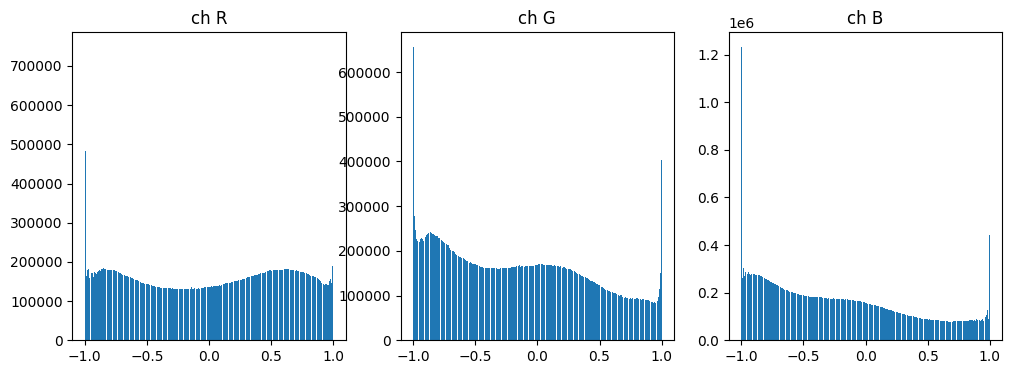

In [26]:
ddpmeval.image_channel_histograms(dl=val_dl)

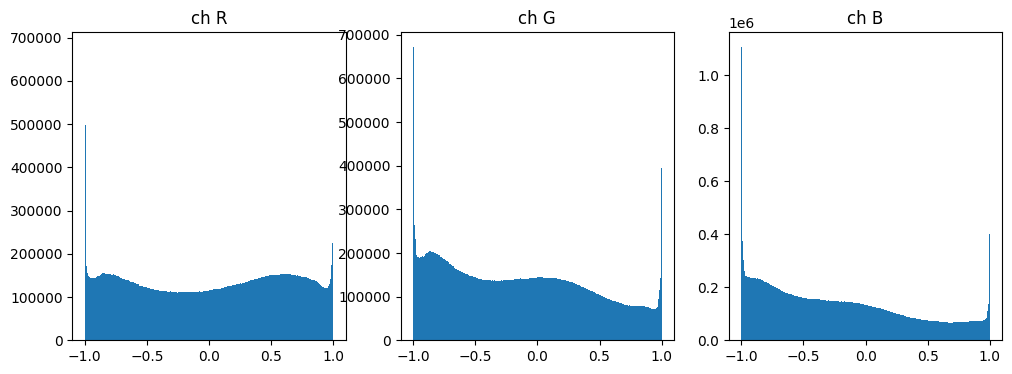

In [39]:
def look_p0(cfg, mdl, dl):
    ddpm = train.DDPMTrainer(cfg=cfg).to(cfg['device'])
    x1s = []
    t = 1
    for x0 in dl:
        x0 = x0.to(cfg['device'])
        t_tensor = torch.full((x0.size()[0],), 1).to(x0.device)
        pred_eps, eps, _, x1 = ddpm.predict_noise(x0=x0, mdl=mdl, t=t_tensor)
        x1s.append(x1)
    ddpmeval.image_channel_histograms(x1s, clip=True)

look_p0(cfg=cfg, mdl=mdl, dl=val_dl)

# Loss Error?

* how well do we do across all the t values?

In [36]:
t_stats = ddpmeval.eval_stats_per_t(mdl=mdl, dl=val_dl, cfg=cfg)

Evaluating time based model stats:   0%|          | 0/10000 [00:00<?, ?it/s]

Evaluating time based model stats:   0%|                                     | 0/15 [33:54<?, ?it/s]


In [37]:
for k in t_stats:
    print(k, t_stats[k][3].shape)

loss_t (10, 1000)
pred_eps_t_mu (10, 1000)
pred_eps_t_std (10, 1000)


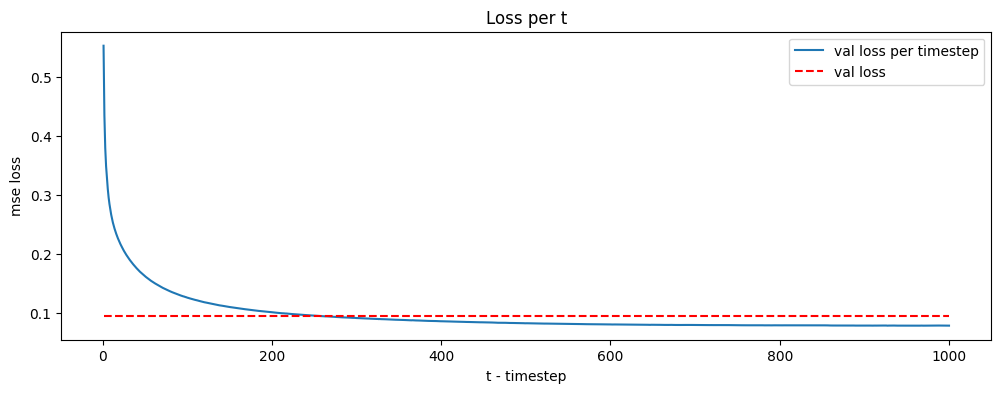

In [43]:
ddpmeval.plot_stats_per_t_loss(t_stats, figsize=(12,4))

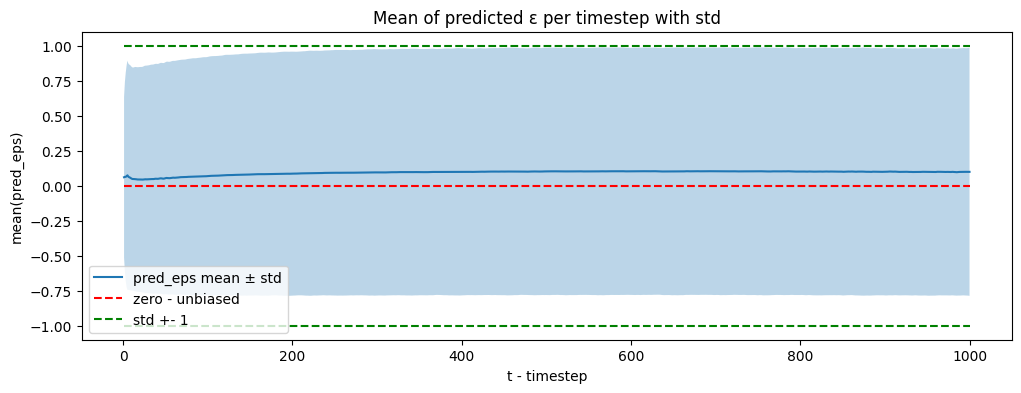

In [46]:
ddpmeval.plot_mu_std_per_t(t_stats, figsize=(12,4))

# Constants/Bug?
* Appendix B of paper - beta1=10-4 betaT=0.02 T=1000

In [47]:
ddpm = train.DDPMTrainer(cfg=cfg)

In [50]:
ddpm.alpha_bars[0:5], ddpm.alpha_bars[-5:]

(tensor([0.9999, 0.9999, 0.9998, 0.9996, 0.9995]),
 tensor([4.3750e-05, 4.2877e-05, 4.2022e-05, 4.1182e-05, 4.0358e-05]))

In [51]:
cfg["diffusion_noise_schedule"]

{'num_timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02}

In [52]:
1e-4

0.0001

In [59]:
        noise_schedule_cfg = cfg["diffusion_noise_schedule"]
        beta_start = noise_schedule_cfg["beta_start"]
        beta_end = noise_schedule_cfg["beta_end"]
        TT = noise_schedule_cfg["num_timesteps"]

        betas = torch.linspace(beta_start, beta_end, TT)
        alphas = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, dim=0)

        # we want to index as in the paper - 1-up, not 0-up
        betas = torch.cat([betas[:1], betas])
        alphas = torch.cat([alphas[:1], alphas])
        alpha_bars = torch.cat([alpha_bars[:1], alpha_bars])


In [60]:
torch.set_printoptions(precision=5)
betas[0:3], betas[-3:]

(tensor([1.00000e-04, 1.00000e-04, 1.19920e-04]),
 tensor([0.01996, 0.01998, 0.02000]))

In [61]:
alphas[0:3], alphas[-3:]

(tensor([0.99990, 0.99990, 0.99988]), tensor([0.98004, 0.98002, 0.98000]))

In [62]:
alpha_bars[0:3], alpha_bars[-3:]

(tensor([0.99990, 0.99990, 0.99978]),
 tensor([4.20215e-05, 4.11819e-05, 4.03583e-05]))

In [66]:
torch.min(torch.randint(1, 1 + 5, (1000,))), torch.max(torch.randint(1, 1 + 5, (1000,)))

(tensor(1), tensor(5))